# Customer Segmentation Using RFM and K-Means Clustering

## Project Summary

This project segments customers based on purchasing behavior using RFM metrics and K-means clustering. The goal is to identify actionable customer groups and support targeted marketing strategies.

## Business Question

How can customers be segmented based on purchasing behavior, and how can these segments be used to improve retention, increase repeat purchases, and maximize customer value?

## Business Objective

Develop customer segments that enable targeted retention, reactivation, upselling, and loyalty strategies.

## Dataset Overview

The dataset contains transaction-level records, including invoice details, product information, quantity, transaction date, unit price, customer ID, and country.

## Method Overview

The analysis constructs customer-level RFM features, applies K-means clustering, profiles the resulting segments, and translates findings into business recommendations.

## 1. Setup and Library Import

In [162]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

## 2. Load and Inspect the Raw Dataset

In [163]:
df_raw = pd.read_csv(
    r"C:\Users\ghaza\Documents\My-Python-Projects\Data-Analysis-with-Python\Customer_segmentation_project\Data\Data.csv"
)

print("Raw shape:", df_raw.shape)
df_raw.head()

Raw shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [164]:
df = df_raw.copy()

In [165]:
print(df.shape)
print(df.columns)
print(df.dtypes)

(541909, 8)
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object


In [166]:
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
Duplicate rows: 5268


Initial Observations: The dataset contains transaction-level retail records. A large number of rows have missing CustomerID values, so they cannot be used for customer-level segmentation. A small number of product descriptions are also missing, though this is less critical for RFM analysis. In addition, the dataset contains duplicate rows, which require further inspection before removal. The next step is to check for returns, cancellations, and invalid transaction values.

In [167]:
print("Missing CustomerID:", df["CustomerID"].isnull().sum())
print("Negative quantity:", (df["Quantity"] < 0).sum())
print("Zero quantity:", (df["Quantity"] == 0).sum())
print("Zero or negative price:", (df["UnitPrice"] <= 0).sum())
print("Missing dates:", df["InvoiceDate"].isnull().sum())

Missing CustomerID: 135080
Negative quantity: 10624
Zero quantity: 0
Zero or negative price: 2517
Missing dates: 0


In [168]:
df["InvoiceNo"] = df["InvoiceNo"].astype(str)
print("Cancellation invoices:", df["InvoiceNo"].str.startswith("C", na=False).sum())

df[df["InvoiceNo"].str.startswith("C", na=False)].head()

Cancellation invoices: 9288


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom


## 3. Clean the Transaction Data and Inspect the Cleaned Dataset

For customer segmentation, the analysis should focus on valid completed purchases linked to known customers. Therefore, rows with missing CustomerID, cancellation or return transactions, non-positive price values, invalid dates, and exact duplicates will be removed. This cleaning step ensures that the dataset reflects valid customer purchases before constructing RFM features.

In [169]:
df_clean = df.dropna(subset=["CustomerID"]).copy()
print("Rows after dropping missing CustomerID:", df_clean.shape[0])

Rows after dropping missing CustomerID: 406829


In [170]:
df_clean["CustomerID"] = df_clean["CustomerID"].astype(int).astype(str)

In [171]:
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"], errors="coerce")

In [172]:
df_clean = df_clean[~df_clean["InvoiceNo"].str.startswith("C", na=False)].copy()

In [173]:
print("Exact duplicates:", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates().copy()
print("Rows after removing duplicates:", df_clean.shape[0])

Exact duplicates: 5192
Rows after removing duplicates: 392732


In [174]:
print("Min date:", df_clean["InvoiceDate"].min())
print("Max date:", df_clean["InvoiceDate"].max())

Min date: 2010-12-01 08:26:00
Max date: 2011-12-09 12:50:00


In [175]:
print(df_clean.shape)
print(df_clean.isnull().sum())
print("Unique customers:", df_clean["CustomerID"].nunique())
print("Unique invoices:", df_clean["InvoiceNo"].nunique())
print(df_clean[["Quantity", "UnitPrice"]].describe())
df_clean = df_clean[df_clean["UnitPrice"] > 0].copy()
print("Rows with UnitPrice <= 0:", (df_clean["UnitPrice"] <= 0).sum())

(392732, 8)
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64
Unique customers: 4339
Unique invoices: 18536
            Quantity      UnitPrice
count  392732.000000  392732.000000
mean       13.153718       3.125596
std       181.588420      22.240725
min         1.000000       0.000000
25%         2.000000       1.250000
50%         6.000000       1.950000
75%        12.000000       3.750000
max     80995.000000    8142.750000
Rows with UnitPrice <= 0: 0


Cleaning Result: The cleaned dataset now represents valid positive purchase transactions associated with known customers. 
This provides a reliable base for customer-level behavioral analysis.

## 4. Create the Transaction Revenue Feature

In [176]:
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]
df_clean[["Quantity", "UnitPrice", "Revenue"]].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [177]:
df_clean["Revenue"].describe()

count    392692.000000
mean         22.631500
std         311.099224
min           0.001000
25%           4.950000
50%          12.450000
75%          19.800000
max      168469.600000
Name: Revenue, dtype: float64

## 5. Define the Snapshot Date

In [178]:
snapshot_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)
print("Snapshot date:", snapshot_date)

Snapshot date: 2011-12-10 12:50:00


## 6. RFM Construction and Validation

- Recency: number of days since the customer's most recent purchase
- Frequency: number of unique invoices for the customer
- Monetary: total revenue generated by the customer

In [179]:
rfm = (
    df_clean.groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("Revenue", "sum")
    )
    .reset_index()
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [180]:
rfm.to_csv("rfm_table.csv", index=False)
print("RFM table saved successfully.")

RFM table saved successfully.


In [181]:
print(rfm.shape)
print(rfm.dtypes)

(4338, 4)
CustomerID     object
Recency         int64
Frequency       int64
Monetary      float64
dtype: object


In [182]:
rfm.isna().sum()

CustomerID    0
Recency       0
Frequency     0
Monetary      0
dtype: int64

In [183]:
print("Unique Customers", rfm["CustomerID"].nunique())
print("Duplicated Customers", rfm["CustomerID"].duplicated().sum())

Unique Customers 4338
Duplicated Customers 0


In [184]:
(rfm["Recency"] < 0).sum()

np.int64(0)

In [185]:
(rfm["Frequency"] <= 0).sum()

np.int64(0)

In [186]:
(rfm["Monetary"] <= 0).sum()

np.int64(0)

Inspecting the Distribution of RFM Variables: Before applying K-means clustering, it is important to examine the distribution of the RFM variables. This helps identify skewness, spread, and potential outliers that may affect the clustering results. Histograms show the overall shape of each variable, while boxplots help highlight extreme values. This step is important because K-means is sensitive to scale and unusually large observations.

In [187]:
rfm[["Recency", "Frequency", "Monetary"]].describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


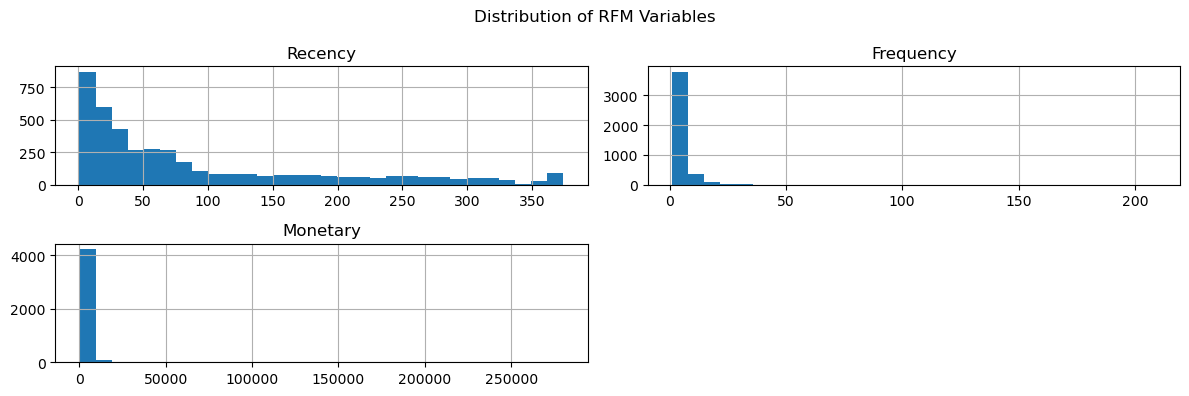

In [188]:
rfm[["Recency", "Frequency", "Monetary"]].hist(figsize=(12, 4), bins=30)
plt.suptitle("Distribution of RFM Variables")
plt.tight_layout()
plt.show()

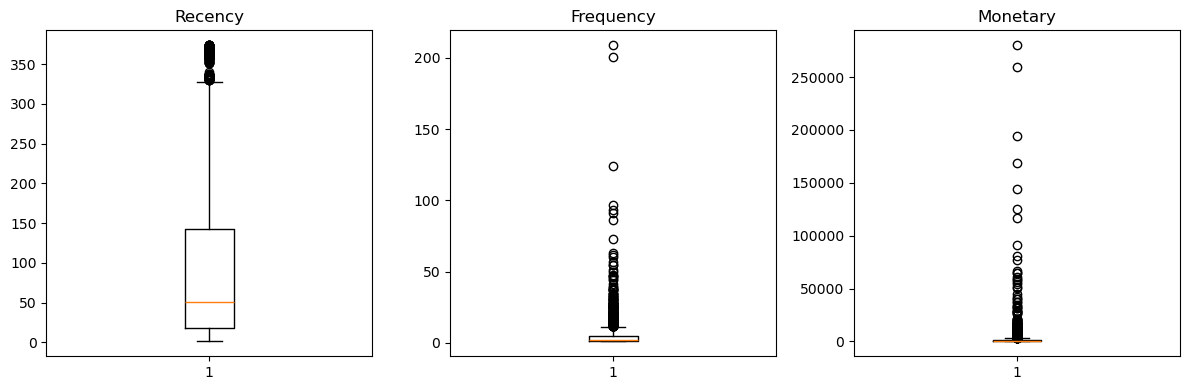

In [189]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.boxplot(rfm["Recency"])
plt.title("Recency")

plt.subplot(1, 3, 2)
plt.boxplot(rfm["Frequency"])
plt.title("Frequency")

plt.subplot(1, 3, 3)
plt.boxplot(rfm["Monetary"])
plt.title("Monetary")

plt.tight_layout()
plt.show()

RFM Table Interpretation: The RFM table contains 4,338 customers and shows no missing values in the three RFM metrics. Recency ranges from 1 to 374 days, indicating a mix of recently active and inactive customers. Frequency and Monetary are both strongly right-skewed: most customers purchase only a few times and spend moderate amounts, while a small group of customers shows very high purchase counts and spending levels. This suggests that scaling, and possibly transformation of Frequency and Monetary, should be considered before clustering.

In [190]:
print("Top customers by Frequency")
display(rfm.sort_values("Frequency", ascending=False).head(10))

print("Top customers by Monetary")
display(rfm.sort_values("Monetary", ascending=False).head(10))

print("Top customers by Recency")
display(rfm.sort_values("Recency", ascending=False).head(10))

Top customers by Frequency


,CustomerID,Recency,Frequency,Monetary
326,12748,1,209,33053.19
1879,14911,1,201,143711.17
4010,17841,2,124,40519.84
562,13089,3,97,58762.08
1661,14606,1,93,12076.15
2176,15311,1,91,60632.75
481,12971,4,86,11189.91
1689,14646,2,73,280206.02
2702,16029,39,63,80850.84
795,13408,2,62,28117.04


Top customers by Monetary


,CustomerID,Recency,Frequency,Monetary
1689,14646,2,73,280206.02
4201,18102,1,60,259657.30
3728,17450,8,46,194390.79
3008,16446,1,2,168472.50
1879,14911,1,201,143711.17
55,12415,24,21,124914.53
1333,14156,10,55,117210.08
3771,17511,3,31,91062.38
2702,16029,39,63,80850.84
0,12346,326,1,77183.60


Top customers by Recency


,CustomerID,Recency,Frequency,Monetary
1749,14729,374,1,313.49
4064,17908,374,1,232.03
355,12791,374,1,192.60
1037,13747,374,1,79.60
3103,16583,374,1,233.45
4108,17968,374,1,265.10
4180,18074,374,1,489.60
4019,17855,373,1,208.97
578,13108,373,1,350.06
3939,17732,373,1,303.97


RFM Interpretation: The RFM table already suggests at least three broad customer patterns. Customers with low Recency and high Frequency appear to represent loyal and active customers. Customers with low Recency and very high Monetary values appear to be high-value customers, even when their purchase frequency is only moderate. In contrast, customers with high Recency, low Frequency, and low Monetary values appear to represent inactive or churned customers.

Inspection of the highest RFM values suggests that the extreme observations reflect meaningful differences in customer behavior rather than obvious data errors. The highest-frequency customers are mostly recent and high-value customers, indicating a loyal and active segment. The highest-monetary customers include both frequent purchasers and customers with only a few very large purchases, suggesting that customer value is driven by both purchase frequency and order size. The highest-recency customers are mostly low-frequency, lower-value customers who have not purchased for a long time, which is consistent with inactive or churned behavior. Therefore, these observations should not be removed automatically. Instead, skewness should be handled carefully, and the variables should be scaled before clustering.

In [191]:
rfm[["Recency", "Frequency", "Monetary"]].skew()

Recency       1.246048
Frequency    12.067031
Monetary     19.339368
dtype: float64

## 7. Reduce Skewness with Log Transformation

In [192]:
rfm_log = rfm.copy()

for col in ["Recency", "Frequency", "Monetary"]:
    rfm_log[col] = np.log1p(rfm_log[col])

In [193]:
rfm_log[["Recency", "Frequency", "Monetary"]].skew()

Recency     -0.379169
Frequency    1.208652
Monetary     0.396599
dtype: float64

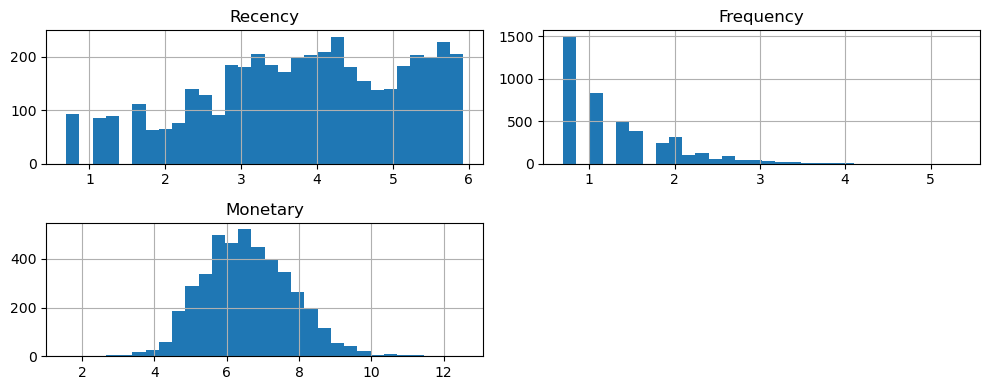

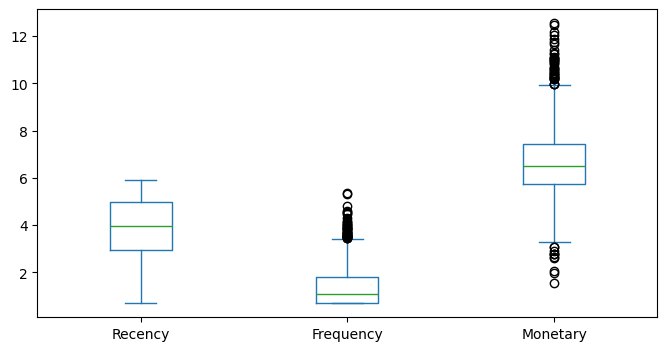

In [194]:
rfm_log[["Recency", "Frequency", "Monetary"]].hist(bins=30, figsize=(10,4))
plt.tight_layout()
plt.show()

rfm_log[["Recency", "Frequency", "Monetary"]].plot(kind="box", figsize=(8,4))
plt.show()

 ## 8. Scale the Transformed RFM Features

In [195]:
from sklearn.preprocessing import RobustScaler

X = rfm_log[["Recency", "Frequency", "Monetary"]]
scaler = RobustScaler()
rfm_scaled = scaler.fit_transform(X)

After applying a log transformation, the skewness of the RFM variables improved substantially. Monetary became approximately symmetric, and Recency showed only mild left skewness. Frequency remained moderately right-skewed, but at a much lower level than before. Since these extreme values likely reflect real customer behavior, no observations were removed at this stage. A robust scaling approach was selected to reduce the influence of remaining extreme values before clustering.

In [196]:
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"],
    index=rfm.index
)

rfm_scaled.head()

,Recency,Frequency,Monetary
0,0.910975,-0.369070,2.813866
1,-1.413309,0.892789,1.103830
2,0.188015,0.464974,0.585572
3,-0.473399,-0.369070,0.572343
4,0.886120,-0.369070,-0.409759


In [197]:
rfm_scaled.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4.338000e+03
mean,-0.059705,0.224802,4.856011e-02
std,0.664020,0.621788,7.459105e-01
min,-1.614193,-0.369070,-2.933106e+00
25%,-0.498812,-0.369070,-4.612708e-01
50%,0.000000,0.000000,-2.632240e-16
75%,0.501188,0.630930,5.387292e-01
max,0.978833,3.867147,3.578086e+00


The transformed RFM features were scaled using RobustScaler, which centers each variable at its median and scales by its interquartile range. As a result, the three variables are now on comparable scales, while the effect of remaining extreme values has been reduced. The processed dataset is suitable for clustering.

## 9. Determine the Optimal Number of Clusters

In [198]:
k_values = range(2, 11)   # try 2 through 10
inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=20,
        max_iter=300,
        random_state=42
    )
    labels = kmeans.fit_predict(rfm_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, labels))

print("Inertias:", inertias)
print("Silhouette scores:", silhouette_scores)

Inertias: [2996.452615234628, 2257.1865409463758, 1832.674427379428, 1533.3708341636304, 1328.6262473771415, 1187.1512586785227, 1086.2307745593826, 997.9313392700176, 926.2086447743136]
Silhouette scores: [0.42980056588784993, 0.3315325100451142, 0.3339933081320258, 0.31277715046030974, 0.309973066497661, 0.3058432944963468, 0.27997672781249944, 0.2844448158662422, 0.279912786272222]


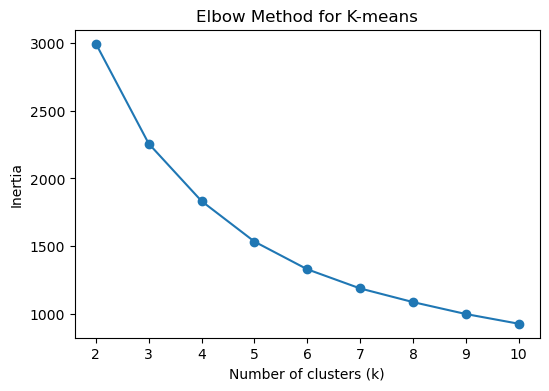

In [199]:
plt.figure(figsize=(6,4))
plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-means")
plt.xticks(list(k_values))
plt.show()

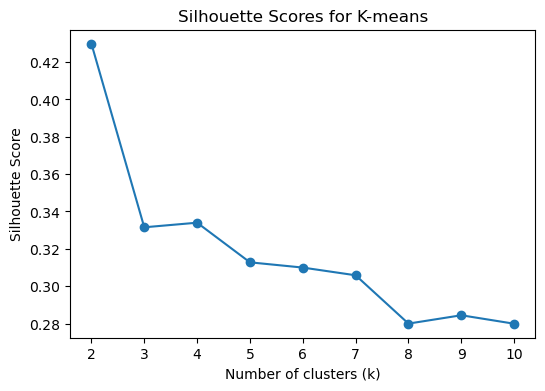

In [200]:
plt.figure(figsize=(6,4))
plt.plot(list(k_values), silhouette_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for K-means")
plt.xticks(list(k_values))
plt.show()

In [201]:
k_results = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette_score": silhouette_scores
})

k_results

,k,inertia,silhouette_score
0,2,2996.452615,0.429801
1,3,2257.186541,0.331533
2,4,1832.674427,0.333993
3,5,1533.370834,0.312777
4,6,1328.626247,0.309973
5,7,1187.151259,0.305843
6,8,1086.230775,0.279977
7,9,997.931339,0.284445
8,10,926.208645,0.279913


Although k = 2 produced the highest silhouette score, it is too coarse to capture meaningful differences across customer groups. The elbow curve shows a noticeable reduction in inertia up to around k = 4, after which the gains become more gradual. Since k = 4 also provides a slightly higher silhouette score than k = 3, it offers a reasonable balance between cluster quality and business interpretability.

## 10. Fit the Final K-Means Model

In [202]:
final_k = 4

kmeans_final = KMeans(
    n_clusters=final_k,
    init="k-means++",
    n_init=20,
    max_iter=300,
    random_state=42
)

rfm_ready = rfm.copy()
rfm_ready["Cluster"] = kmeans_final.fit_predict(rfm_scaled)

rfm_ready.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346,326,1,77183.60,3
1,12347,2,7,4310.00,0
2,12348,75,4,1797.24,3
3,12349,19,1,1757.55,2
4,12350,310,1,334.40,1


## 11. Profile the Customer Clusters

In [205]:
rfm_ready["Cluster"].value_counts().sort_index()

Cluster
0     727
1    1552
2     839
3    1220
Name: count, dtype: int64

In [208]:
cluster_summary = rfm_ready.groupby("Cluster").agg(
    Recency=("Recency", "mean"),
    Frequency=("Frequency", "mean"),
    Monetary=("Monetary", "mean"),
    Count=("CustomerID", "count")
)

cluster_summary


,Recency,Frequency,Monetary,Count
Cluster,,,,
0,12.760660,13.602476,8042.478171,727
1,183.056057,1.303479,309.188345,1552
2,17.785459,2.232420,560.017545,839
3,76.328689,3.890984,1713.616584,1220


In [209]:
cluster_summary["Percent"] = (
    cluster_summary["Count"] / cluster_summary["Count"].sum() * 100
).round(2)

cluster_summary

,Recency,Frequency,Monetary,Count,Percent
Cluster,,,,,
0,12.760660,13.602476,8042.478171,727,16.76
1,183.056057,1.303479,309.188345,1552,35.78
2,17.785459,2.232420,560.017545,839,19.34
3,76.328689,3.890984,1713.616584,1220,28.12


The 4-cluster solution reveals meaningful differences in customer behavior. Cluster 0 contains the most valuable customers, with very recent purchases, the highest purchase frequency, and the highest spending. Cluster 1 represents inactive low-value customers, characterized by high recency, low frequency, and low monetary value. Cluster 2 includes recent but still low-value customers, who may represent newer or developing customers with growth potential. Cluster 3 captures regular mid-value customers, who purchase with moderate frequency and spending and may be strong candidates for retention and upselling strategies.

## 12. Assign Business Segment Labels

In [210]:
cluster_labels = {
    0: "Loyal High-Value Customers",
    1: "Inactive / Lost Customers",
    2: "Recent Low-Value Customers",
    3: "Regular Mid-Value Customers"
}

rfm_ready["Segment"] = rfm_ready["Cluster"].map(cluster_labels)
rfm_ready.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346,326,1,77183.60,3,Regular Mid-Value Customers
1,12347,2,7,4310.00,0,Loyal High-Value Customers
2,12348,75,4,1797.24,3,Regular Mid-Value Customers
3,12349,19,1,1757.55,2,Recent Low-Value Customers
4,12350,310,1,334.40,1,Inactive / Lost Customers


## 13. Translate the Segments into Business Actions

Managerial Actions: The cluster structure suggests clear strategic actions for each customer group. Loyal high-value customers should be rewarded and retained through VIP offers, loyalty programs, and personalized communication. Inactive customers should be targeted with reactivation campaigns and win-back offers, while keeping marketing costs controlled. Recent low-value customers should be nurtured to encourage repeat purchases through onboarding, cross-selling, and follow-up engagement. Regular mid-value customers should be targeted with upselling, product recommendations, and retention campaigns to increase their long-term value.